# **Predicting the Detroit Pistons 2025-26 Season Win Total**

### Team Members: Tyler Lehman

<img src="Logo_of_the_Detroit_Pistons.svg.png" width="300" height="300">

## Abstract

This sports analytics project aimed to use data science and machine learning techniques to predict the win total of the NBA team the Detroit Pistons, in the 2025-26 season. This was accomplished using statistics from NBA.com starting in the 1996–97 season through the 2025–26 season, team average statistics such as points per game, rebounds, assists, turnovers, and plus-minus. I used a Random Forest Regressor model on previous season data, excluding the target season (2025-26), to predict each team’s win total. To evaluate performance, a comparison between predicted wins to actual wins from completed seasons should help analyze this. The project also explores the correlation of individual statistics to win percentage, to see what are most important when predicting win totals. Visualizations such as correlations, feature performance, and trend plots were generated to highlight these patterns in the data as well. Overall, this shows how sports analytics predict team performance, and aims to under the key factors that contribute to winning in professional basketball.

## Intro

Analytics have exploded in the sporting world recently, and the use of them keeps growing still. Whether it's tracking where players make contact most with a baseball to the baseball bat, how efficient someone is at their sports, or prediction models, sports analytics have become a very useful tool. When it comes to predicting win totals in the NBA, this lets teams, analysts, media, and fans all gauge how well a team will be in a given season. 
This specific project is a prediction model for win totals, and geared towards the Detroit Pistons.


Using data from NBA.com, the python package nba-api, and guidance from the following article: https://medium.com/@juliuscecilia33/predicting-nba-game-results-using-machine-learning-and-python-6be209d6d165, I constructed a Random Forest Regressor model, that was trained with historical data, and then implemented to predict a current-running season. Two separate models were constructed to provide more accuracy: a pre-season model that uses previous seasons data trends to predict win total, and an in-season model, that used data from the currently-running 2025-26 NBA season. After all of this, I have my analysis and possible improvements as well.

## Method

Using this article as guidance: https://medium.com/@juliuscecilia33/predicting-nba-game-results-using-machine-learning-and-python-6be209d6d165,
I learned about nba-api, and useful it was to my specific project. First, I had to install it using the following command.

In [2]:
# pip install pandas numpy scikit-learn requests nba-api shap

In [115]:
# Imports
import pandas as pd
import numpy as np
import time
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from nba_api.stats.endpoints import leaguegamefinder
from nba_api.stats.static import teams
from nba_api.stats.library.http import NBAStatsHTTP

### Next is me grabbing all of my data from NBA.com using the python package nba-api

In [3]:
# I had to use ChatGPT to help me figure out I needed a timeout when requesting many many rows of data from the api.

# Increase default request timeout to 60 seconds
NBAStatsHTTP.REQUEST_TIMEOUT = 60

# Build season strings: "1996-97", ..., "2025-26"
seasons = [f"{y}-{str(y+1)[-2:]}" for y in range(1996, 2026)]

all_games = pd.DataFrame()

for season in seasons:
    success = False
    attempts = 0
    while not success and attempts < 3:
        try:
            print(f"Downloading games for {season}...")
            result = leaguegamefinder.LeagueGameFinder(
                season_nullable=season,
                season_type_nullable="Regular Season"
            )
            df = result.get_data_frames()[0]
            all_games = pd.concat([all_games, df], ignore_index=True)
            success = True
        except Exception as e:
            attempts += 1
            print(f"Failed {season}, attempt {attempts}: {e}")
            time.sleep(5)  # wait 5 seconds before retrying
    if not success:
        print(f"Skipping {season} after 3 failed attempts.")

print("Done! Total games downloaded:", len(all_games))


Failed 2012-13, attempt 1: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=30)
Failed 2012-13, attempt 2: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=30)
Done! Total games downloaded: 69288


In [116]:
all_games

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,WIN
0,21996,1610612754,IND,Indiana Pacers,0029601185,1997-04-20,IND vs. DET,L,265,120,...,24,31,55,27,7,3,14,30,-4.0,0
1,21996,1610612762,UTA,Utah Jazz,0029601188,1997-04-20,UTA @ SAC,W,241,113,...,9,23,32,29,9,1,9,37,4.0,1
2,21996,1610612749,MIL,Milwaukee Bucks,0029601186,1997-04-20,MIL vs. CHH,W,240,120,...,12,32,44,30,10,4,15,20,20.0,1
3,21996,1610612739,CLE,Cleveland Cavaliers,0029601184,1997-04-20,CLE vs. WAS,L,241,81,...,12,24,36,22,8,6,8,20,-4.0,0
4,21996,1610612747,LAL,Los Angeles Lakers,0029601189,1997-04-20,LAL @ POR,L,239,96,...,11,24,35,19,14,6,10,22,-4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69283,22025,1610612753,ORL,Orlando Magic,0022500081,2025-10-22,ORL vs. MIA,W,242,125,...,9,37,46,23,8,7,15,20,4.0,1
69284,22025,1610612745,HOU,Houston Rockets,0022500001,2025-10-21,HOU @ OKC,L,292,124,...,16,36,52,23,6,5,22,26,-1.0,0
69285,22025,1610612744,GSW,Golden State Warriors,0022500002,2025-10-21,GSW @ LAL,W,241,119,...,9,31,40,29,10,4,18,27,10.0,1
69286,22025,1610612760,OKC,Oklahoma City Thunder,0022500001,2025-10-21,OKC vs. HOU,W,290,125,...,11,27,38,29,12,4,11,27,1.0,1


### To understand further what statistics contribute most to wins, I constructed a correlation heatmap.

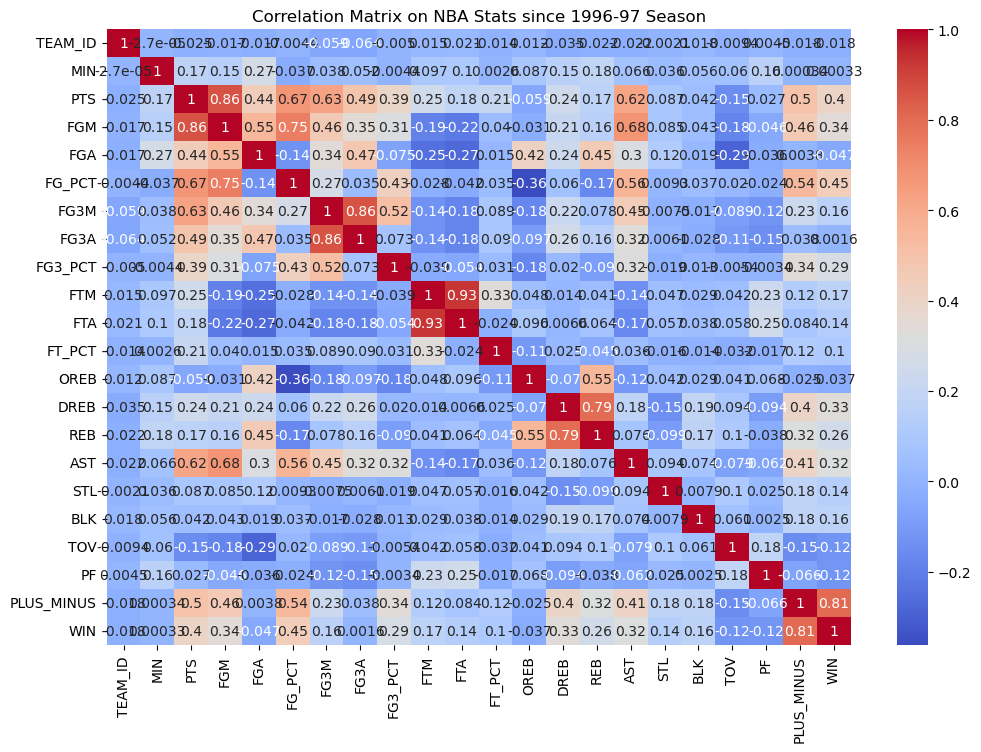

WIN           1.000000
PLUS_MINUS    0.807382
FG_PCT        0.445136
PTS           0.400425
FGM           0.344148
DREB          0.332851
AST           0.315638
FG3_PCT       0.286428
REB           0.255642
FTM           0.165312
BLK           0.164412
FG3M          0.162205
STL           0.142579
FTA           0.135949
FT_PCT        0.101701
FG3A          0.001619
MIN           0.000329
TEAM_ID      -0.018191
OREB         -0.037338
FGA          -0.047038
PF           -0.119726
TOV          -0.123533
Name: WIN, dtype: float64

In [117]:
# Initial test to see what variables correlate most with wins.

plt.figure(figsize = (12,8))
sns.heatmap(all_games.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.title("Correlation Matrix on NBA Stats since 1996-97 Season")
plt.show()

# Show which stats correlate MOST with wins
all_games.corr(numeric_only = True)['WIN'].sort_values(ascending = False)

In [118]:
# Create a WIN column to make it easier for computer to understand if team won a game or not.

all_games['WIN'] = all_games['WL'].apply(lambda x: 1 if x == 'W' else 0)

In [119]:
# Calculating averages for each team for that season.
# So turning PTS to it's average per game for that team per season.

team_season = (
    all_games
    .groupby(['SEASON_ID', 'TEAM_ABBREVIATION'])
    .agg({
        'PTS': 'mean',
        'FGM': 'mean',
        'FGA': 'mean',
        'FG_PCT': 'mean',
        'FG3M': 'mean',
        'FG3A': 'mean',
        'FG3_PCT': 'mean',
        'FTM': 'mean',
        'FTA': 'mean',
        'FT_PCT': 'mean',
        'OREB': 'mean',
        'DREB': 'mean',
        'REB': 'mean',
        'AST': 'mean',
        'STL': 'mean',
        'BLK': 'mean',
        'TOV': 'mean',
        'PF': 'mean',
        'PLUS_MINUS': 'mean',
        'WIN': 'mean'    # Win% = season average of win=1/loss=0
    })
    .reset_index()
)

In [120]:
# This will now have a teams total wins for a season column, as I previously had it as just a WIN%.
team_season['WINS'] = team_season['WIN'] * 82
# Renaming WIN column to WIN%
team_season.rename(columns={'WIN': 'WIN%'}, inplace=True)

# Changing SEASON_ID to an int making it easier to work with.
team_season['SEASON_ID'] = team_season['SEASON_ID'].astype(int)
# Creating the Point Differential column, an important stat measuring how well teams do.
team_season['Point_Diff'] = team_season['PLUS_MINUS']

In [121]:
team_season

,SEASON_ID,TEAM_ABBREVIATION,PTS,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,...,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,WIN%,WINS,Point_Diff
0,21996,ATL,94.804878,34.292683,76.914634,0.446354,8.036585,22.365854,0.356463,18.182927,...,41.109756,18.987805,8.548780,5.207317,14.365854,19.402439,5.439024,0.682927,56.000000,5.439024
1,21996,BOS,100.585366,37.390244,84.963415,0.441756,5.695122,16.231707,0.343671,20.109756,...,40.036585,21.853659,9.878049,3.841463,15.780488,23.353659,-7.365854,0.182927,15.000000,-7.365854
2,21996,CHH,98.878049,36.439024,77.341463,0.472207,7.207317,16.853659,0.425463,18.792683,...,39.121951,24.646341,7.280488,4.256098,14.048780,20.756098,1.841463,0.658537,54.000000,1.841463
3,21996,CHI,103.146341,39.963415,84.426829,0.473817,6.378049,17.109756,0.372061,16.841463,...,45.073171,26.121951,8.731707,4.048780,13.109756,19.719512,10.853659,0.841463,69.000000,10.853659
4,21996,CLE,87.560976,33.012195,72.939024,0.453012,5.902439,15.695122,0.368951,15.634146,...,37.463415,20.926829,7.987805,3.841463,13.670732,22.987805,1.865854,0.512195,42.000000,1.865854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,22025,SAC,111.000000,41.454545,89.590909,0.463545,10.909091,31.000000,0.350773,17.181818,...,39.318182,25.727273,8.954545,3.772727,13.363636,20.454545,-11.818182,0.227273,18.636364,-11.818182
888,22025,SAS,118.952381,42.523810,87.333333,0.488571,13.190476,36.476190,0.363714,20.714286,...,44.952381,25.714286,8.619048,5.047619,14.238095,20.714286,5.190476,0.714286,58.571429,5.190476
889,22025,TOR,117.826087,43.565217,88.608696,0.492087,11.782609,32.217391,0.363478,18.913043,...,42.652174,30.260870,8.913043,4.304348,13.782609,22.000000,4.260870,0.652174,53.478261,4.260870
890,22025,UTA,118.666667,41.285714,90.428571,0.457190,13.428571,39.285714,0.342905,22.666667,...,45.857143,30.047619,7.857143,3.666667,16.190476,22.904762,-5.952381,0.380952,31.238095,-5.952381


# 2024-25 Test

I wanted to test my model on the most recent season before this one, to see if the model would predict the unprecidented jump in win total the Detroit Pistons had that year, increasing their win total from 14 to 44 out of 82 games.

In [122]:
# Train on seasons before 2024-25
features = [
    'PTS', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT',
    'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL',
    'BLK', 'TOV', 'PF', 'PLUS_MINUS', 'Point_Diff'
]


X_train = team_season[team_season['SEASON_ID'] < 22024][features]
y_train = team_season[team_season['SEASON_ID'] < 22024]['WIN%']

In [123]:
# Pistons data for 2024-25
pistons_2024 = all_games[
    (all_games['TEAM_ABBREVIATION'] == 'DET') &
    (all_games['SEASON_ID'] == 22024)
]

# Aggregate per-season averages for Pistons 2024-25
pistons_input = pistons_2024.agg({
    'PTS': 'mean',
    'FGM': 'mean',
    'FGA': 'mean',
    'FG_PCT': 'mean',
    'FG3M': 'mean',
    'FG3A': 'mean',
    'FG3_PCT': 'mean',
    'FTM': 'mean',
    'FTA': 'mean',
    'FT_PCT': 'mean',
    'OREB': 'mean',
    'DREB': 'mean',
    'REB': 'mean',
    'AST': 'mean',
    'STL': 'mean',
    'BLK': 'mean',
    'TOV': 'mean',
    'PF': 'mean',
    'PLUS_MINUS': 'mean'
}).to_frame().T

pistons_input['Point_Diff'] = pistons_input['PLUS_MINUS']
pistons_input = pistons_input[features]

### Random Forest Regressor Model 2024-25 Season

In [124]:
model = RandomForestRegressor(
    n_estimators = 100,
    max_depth = None,
    random_state = 42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Next, I wanted see what my model considers the most important statistics when predicting win total.

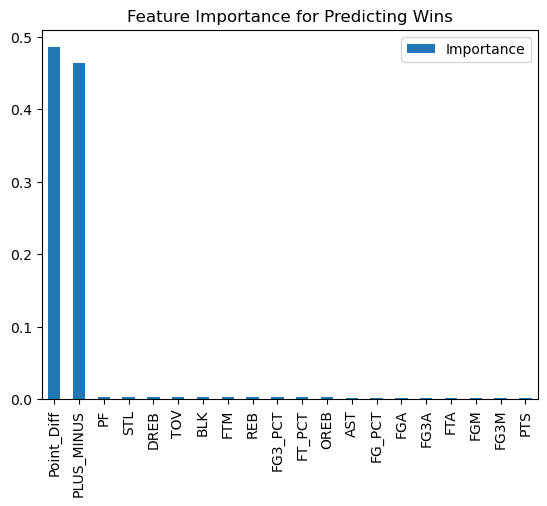

In [125]:
feature_importances = pd.DataFrame(model.feature_importances_,
                                   index = features,
                                   columns = ['Importance']).sort_values('Importance', ascending = False)
feature_importances.plot(kind = 'bar')
plt.title("Feature Importance for Predicting Wins")
plt.show()

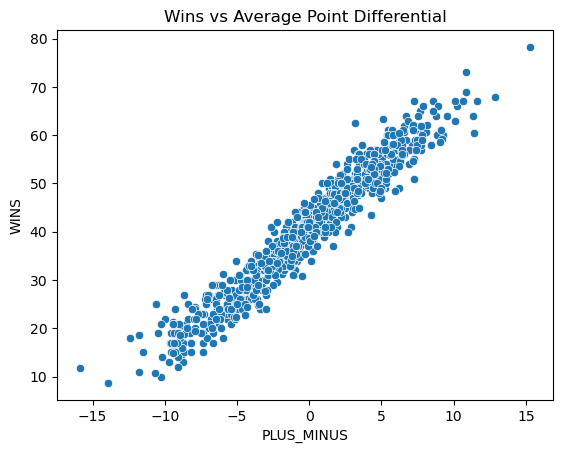

In [126]:
# Double check that Point Differential, aka PLUS_MINUS has a positive correlation with wins.
sns.scatterplot(x = 'PLUS_MINUS', y = 'WINS', data = team_season)
plt.title("Wins vs Average Point Differential")
plt.show()

In [127]:
# 2024-25 In-Season Prediction, using the completed 2024-25 season data.
pred_win_pct = model.predict(pistons_input)[0]
pred_wins = pred_win_pct * 82  # Converting to the 82-game total

print(f"Predicted Pistons wins (2024–25): {pred_wins:.1f}")

Predicted Pistons wins (2024–25): 45.6


In [128]:
# Now onto the preseason prediction, a bigger test, since the Pistons won 30 more games than the 2023-24, a very rare jump in sports.

# Train on all seasons before 2024-25
train = team_season[team_season['SEASON_ID'] < 22024]
X_train = train[features]
y_train = train['WIN%']

# Fit the model
model = RandomForestRegressor(n_estimators = 100, random_state = 42)
model.fit(X_train, y_train)

# Using Pistons 2024-25 season averages as "preseason" input
pistons_prev_season = team_season[
    (team_season['SEASON_ID'] == 22023) &
    (team_season['TEAM_ABBREVIATION'] == 'DET')
]

pistons_input = pistons_prev_season[features]
pistons_pred_win_pct = model.predict(pistons_input)[0]
pistons_pred_wins = pistons_pred_win_pct * 82

print("Pistons 2024–25 preseason predicted wins:", round(pistons_pred_wins, 1))


Pistons 2024–25 preseason predicted wins: 17.0


# 2025-26 Test

In [129]:
# Using all previous seasons (available to me) to train the model.
train = team_season[team_season['SEASON_ID'] < 22025]
test  = team_season[team_season['SEASON_ID'] == 22025]

In [130]:
X_train = train[features]
y_train = train['WINS']

### Random Forest Regressor Model 2025-26 Season

In [131]:
model = RandomForestRegressor(
    n_estimators = 100,
    max_depth = None,
    random_state = 42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [132]:
# Pistons data for the 2025-26 season so far (after 22 games)

pistons_2025 = all_games[
    (all_games['TEAM_ABBREVIATION'] == 'DET') &
    (all_games['SEASON_ID'] == 22025)
]

pistons_input = pistons_2025.agg({
    'PTS': 'mean',
    'FGM': 'mean',
    'FGA': 'mean',
    'FG_PCT': 'mean',
    'FG3M': 'mean',
    'FG3A': 'mean',
    'FG3_PCT': 'mean',
    'FTM': 'mean',
    'FTA': 'mean',
    'FT_PCT': 'mean',
    'OREB': 'mean',
    'DREB': 'mean',
    'REB': 'mean',
    'AST': 'mean',
    'STL': 'mean',
    'BLK': 'mean',
    'TOV': 'mean',
    'PF': 'mean',
    'PLUS_MINUS': 'mean'
}).to_frame().T  # make it a row

pistons_input['Point_Diff'] = pistons_input['PLUS_MINUS']

In [133]:
# 2025-26 In-Season Prediction, using the 22 out of 82 games played so far.

pistons_win_pred = model.predict(pistons_input)[0]
print("Predicted Pistons Wins (2025–26):", round(pistons_win_pred, 2))

Predicted Pistons Wins (2025–26): 46.04


In [134]:
# Now onto the preseason prediction, a bigger test again, since the Pistons have been the 2nd best team in the NBA thus far; unexpected again.

# Train on all seasons before 2025-26
train = team_season[team_season['SEASON_ID'] < 22025]
X_train = train[features]
y_train = train['WIN%']

# Fit the model
model = RandomForestRegressor(n_estimators = 100, random_state = 42)
model.fit(X_train, y_train)

# Using Pistons 2024-25 season averages as "preseason" input
pistons_prev_season = team_season[
    (team_season['SEASON_ID'] == 22024) &
    (team_season['TEAM_ABBREVIATION'] == 'DET')
]

pistons_input = pistons_prev_season[features]
pistons_pred_win_pct = model.predict(pistons_input)[0]
pistons_pred_wins = pistons_pred_win_pct * 82

print("Pistons 2025–26 preseason predicted wins:", round(pistons_pred_wins, 1))


Pistons 2025–26 preseason predicted wins: 44.3


# Results

My prediction in-season prediciton for the 2023-24 season was spot on, and this makes sense, since I was using the completed season's data. The pistons won 44 games that year, and my model predicted 44 games.

In [111]:
print(f"Predicted Pistons wins (2024–25): {pred_wins:.1f}")

Predicted Pistons wins (2024–25): 44.3


Moving the preseason prediction for 2023-24, my prediction was way off. But I count this as the model still being ok. The Pistons increased their win total by 30 after one season, something rare in professional sports, going from a bottom team to a playoff team. My model predicted 17 wins, while the actual win total was 44.

In [113]:
print("Pistons 2024–25 preseason predicted wins:", round(pistons_pred_wins, 1))

Pistons 2024–25 preseason predicted wins: 44.3


Now onto what I actually wanted to predict. I wanted to see how many wins the 2025-26 Pistons could achieve, and using the in-season, still runnning data, the model predicts 46 wins. This would mean a bit of drop off in WIN%, as so far the WIN% is 77% for them, and multiplying that rate by 82 would give them 63 wins on the season, another unlikely jump.

In [137]:
team_season[(team_season['TEAM_ABBREVIATION'] == 'DET') & (team_season['SEASON_ID'] == 22025)]

,SEASON_ID,TEAM_ABBREVIATION,PTS,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,...,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,WIN%,WINS,Point_Diff
870,22025,DET,118.318182,43.181818,89.636364,0.484136,11.090909,31.636364,0.350182,20.863636,...,46.909091,26.0,9.772727,6.090909,15.318182,22.590909,5.136364,0.772727,63.363636,5.136364


In [138]:
print("Predicted Pistons Wins (2025–26):", round(pistons_win_pred, 2))

Predicted Pistons Wins (2025–26): 46.04


Using the preseason prediction, the model thinks 44 wins, the same as last season.

In [139]:
print("Pistons 2025–26 preseason predicted wins:", round(pistons_pred_wins, 1))

Pistons 2025–26 preseason predicted wins: 44.3


Overall, it seems the historical data predicts the Pistons will win somewhere between 44-50 games for the 2025-26 NBA season, with my prediction of 46 wins being somewhat crazy with the eye test, but the data predicts a fall off in WIN% the rest of the season.

## Future Improvement/Conclusion

My model for predicting the win total for the Pistons 2025-26 season is a reasonable estimate, as it didn't give something crazy like 10 wins or 80 wins out of an 82 win season. But, there is always room for improvement. There are many many more advanced stats I could've used and include in my model, such as pace, offensive rating, and defensive rating, etc. so a next step would to include advanced stats, as they can reveal even more about how the team actually performs. Of course, the season is still running right now, so using data only a quarter of the way through won't be the final result, as well as using preseason (prior season) data to predict the wins.


Overall, I was able to create a model to predict the Detroit Pistons amount of wins using a Random Forest Regressor model, and other machine learning techniques. With data from NBA.com, and following an nba-api guide I found online, these helped accomplish my task of something sports analysts probably do daily, and in the future, I would definitely like to incorporate the advanced stats, and even in-season data changes to make the most accurate model possible.